In [1]:
# ─── CELL 1: Install & Import ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# ─── CELL 2: Load Dataset ────────────────────────────────────────────────────
# Make sure your CSV file is in the same folder as this notebook
# PaySim CSV is usually named: PS_20174392719_1491204439457_log.csv
# Rename it to paysim.csv for convenience

df = pd.read_csv('paysim.csv')   # update filename if different

print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

Shape       : (341829, 11)
Columns     : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 3 rows:
   step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT  9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT  1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER   181.00  C1305486145          181.0            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0      0.0             0.0  
1  M2044282225             0.0             0.0      0.0             0.0  
2   C553264065             0.0             0.0      1.0             0.0  


In [3]:
# ─── CELL 3: Basic Info ──────────────────────────────────────────────────────
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATS ===")
print(df.describe())

=== DATA TYPES ===
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud           float64
isFlaggedFraud    float64
dtype: object

=== MISSING VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64

=== BASIC STATS ===
                step        amount  oldbalanceOrg  newbalanceOrig  \
count  341829.000000  3.418290e+05   3.418290e+05    3.418290e+05   
mean       11.982556  1.745974e+05   8.974672e+05    9.167459e+05   
std         2.868772  2.933899e+05   2.919070e+06    2.956295e+06   
min         1.000000  3.000000e-01   0.000000e+00    0.000000e+00   
25%        10.000000  1.305281e+04   0.000000e+00    0.000

=== FRAUD DISTRIBUTION ===
Legitimate : 341,635  (99.94%)
Fraudulent : 193  (0.06%)


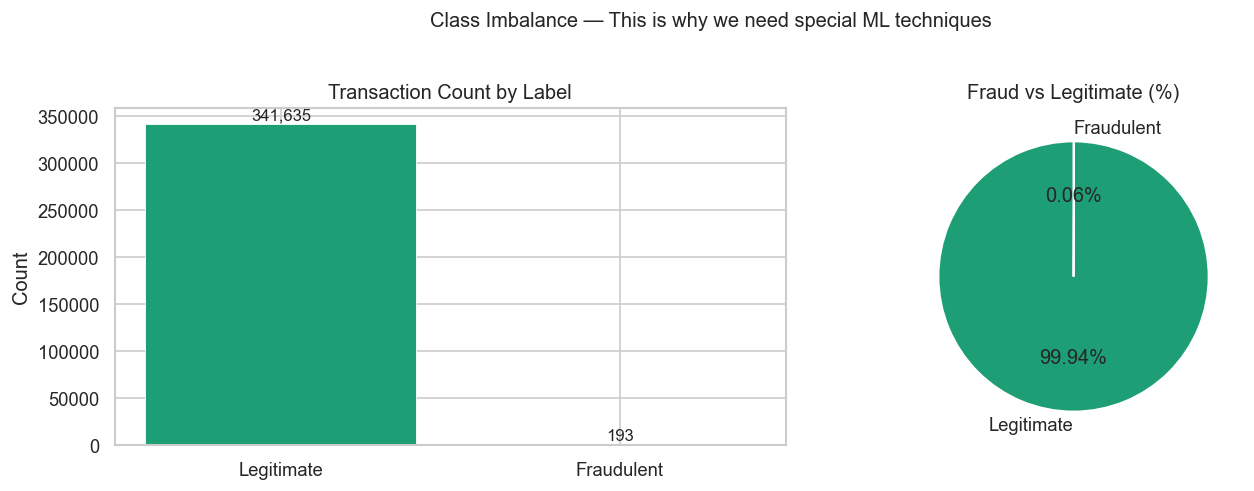

💡 Insight: Massive class imbalance — only ~0.13% fraud. We must handle this carefully.


In [4]:
# ─── CELL 4: Fraud Distribution ──────────────────────────────────────────────
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

print("=== FRAUD DISTRIBUTION ===")
print(f"Legitimate : {fraud_counts[0]:,}  ({fraud_pct[0]:.2f}%)")
print(f"Fraudulent : {fraud_counts[1]:,}  ({fraud_pct[1]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Legitimate', 'Fraudulent'], fraud_counts.values,
            color=['#1D9E75', '#E24B4A'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Transaction Count by Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.2f%%', colors=['#1D9E75', '#E24B4A'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Fraud vs Legitimate (%)')

plt.suptitle('Class Imbalance — This is why we need special ML techniques',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('eda_fraud_distribution.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Massive class imbalance — only ~0.13% fraud. We must handle this carefully.")

=== TRANSACTION TYPES ===
type
CASH_OUT    121306
PAYMENT     116665
CASH_IN      73083
TRANSFER     28302
DEBIT         2473
Name: count, dtype: int64


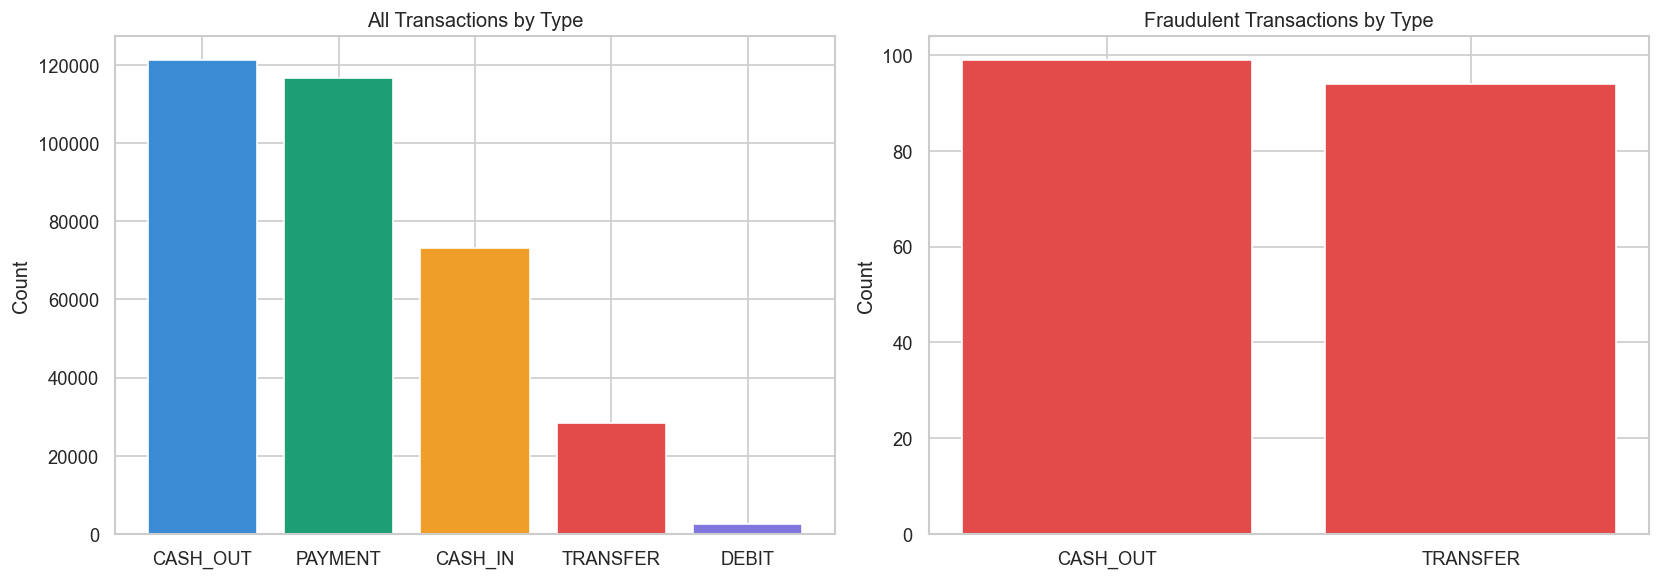

💡 Insight: Fraud only occurs in TRANSFER and CASH_OUT — never in PAYMENT or DEBIT!
   This alone is a massive feature for your model.


In [6]:
# ─── CELL 5: Transaction Types ───────────────────────────────────────────────
print("=== TRANSACTION TYPES ===")
print(df['type'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All transactions by type
type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#3B8BD4','#1D9E75','#EF9F27','#E24B4A','#7F77DD'],
            edgecolor='white')
axes[0].set_title('All Transactions by Type')
axes[0].set_ylabel('Count')

# Fraud by type
fraud_by_type = df[df['isFraud'] == 1]['type'].value_counts()
axes[1].bar(fraud_by_type.index, fraud_by_type.values,
            color='#E24B4A', edgecolor='white')
axes[1].set_title('Fraudulent Transactions by Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_transaction_types.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Fraud only occurs in TRANSFER and CASH_OUT — never in PAYMENT or DEBIT!")
print("   This alone is a massive feature for your model.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution (log scale)
axes[0].hist(np.log1p(df[df['isFraud']==0]['amount']), bins=50,
             color='#1D9E75', alpha=0.7, label='Legitimate', density=True)
axes[0].hist(np.log1p(df[df['isFraud']==1]['amount']), bins=50,
             color='#E24B4A', alpha=0.7, label='Fraudulent', density=True)
axes[0].set_title('Transaction Amount Distribution (log scale)')
axes[0].set_xlabel('log(amount)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot
fraud_labels = df['isFraud'].map({0: 'Legitimate', 1: 'Fraudulent'})
axes[1].boxplot(
    [df[df['isFraud']==0]['amount'].clip(upper=500000),
     df[df['isFraud']==1]['amount'].clip(upper=500000)],
    labels=['Legitimate', 'Fraudulent'],
    patch_artist=True,
    boxprops=dict(facecolor='#1D9E75', alpha=0.6),
)
axes[1].set_title('Amount Boxplot (capped at 500k)')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.savefig('eda_amount_distribution.png', bbox_inches='tight')
plt.show()

print(f"Avg legitimate amount : ₹{df[df['isFraud']==0]['amount'].mean():,.0f}")
print(f"Avg fraudulent amount : ₹{df[df['isFraud']==1]['amount'].mean():,.0f}")
print("💡 Insight: Fraudulent transactions tend to be much larger on average.")

C:\Users\win10\AppData\Local\Temp\ipykernel_10912\2282913603.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
